# chinese-wwm-roberta 逐层分析

三个目标（①②③）：

1. **分析微调模型的每一层** —— 权重统计 + 逐层激活
2. **分析原模型的每一层** —— 用本地底座跑同样的输入
3. **对比 finetune 前后每一层的输出** —— 激活级 + 权重级

数据：
- `chinese-wwm-roberta.ckpt` —— 微调后的模型（含自定义 `fc` 分类头）
- `chinese-roberta-wwm-ext/` —— 本地预训练底座

> 说明：这两个模型同结构同词表（vocab=21128），所以可以逐层对齐比较。

> **P6 勘误（2026-08-12）** —— 本 notebook 是无数据阶段的探索记录，保留原样；结论措辞与统计以本勘误和仓库中的修正实现为准：>> 1. **真实 max abs delta**：notebook 小结中的“最大绝对误差约 1.5e-3”是断言而非计算。现已在 `compare_layers.py` 中真正计算：**0.001488**（`encoder.layer.9.attention.self.key.weight`），数值上恰好印证该断言。> 2. **“高层(layer 8-12)”的措辞**：hidden-state 差异随深度单调增大是**累计表示差异**（每层都作用在上一层差异之上），不由曲线推断某一层自身改动最大。权重级 rel_L2 逐层近似均匀（0.0035→0.0041），最大单张量差异位于 layer 8-10 与 pooler。> 3. **层编号**：hidden index 0 是 embedding；encoder layer 只编号 0-11。任何“encoder layer 12”表述均不成立。> 4. **Masking**：notebook 中激活/注意力统计未排除 padding；修正实现（`src/analysis.py`）只对 `attention_mask==1` 统计，并提供 token-micro 与 sentence-macro 双口径。> 5. **不使用“死 ReLU 神经元”**：底座配置激活函数为 GELU。> 6. 无标签数据时，本 notebook **不做**任何“某层含多少情绪信息 / 任务价值”的结论。>> 修正实现：`compare_layers.py`（重写）+ `src/analysis.py` + `src/checkpoint.py`（显式解包赋值）。

## 0. 环境、路径、设备

In [1]:
import os, torch, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from transformers import AutoConfig, AutoModel, AutoTokenizer

BASE = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta/chinese-roberta-wwm-ext"
CKPT = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta/chinese-wwm-roberta.ckpt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


### 中文字体（否则绘图标题显示成方块）

In [2]:
from matplotlib import font_manager
for fp in ["/usr/share/fonts/wqy-microhei/wqy-microhei.ttc",
           "/usr/share/fonts/wqy-zenhei/wqy-zenhei.ttc"]:
    try:
        font_manager.fontManager.addfont(fp)
    except Exception as e:
        print("跳过字体", fp, e)
plt.rcParams["font.family"] = "WenQuanYi Micro Hei"
plt.rcParams["axes.unicode_minus"] = False
print("中文字体已启用：WenQuanYi Micro Hei")

中文字体已启用：WenQuanYi Micro Hei


## 1. 读取 ckpt，推断结构

In [3]:
ckpt = torch.load(CKPT, map_location="cpu")
sd = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
print("总参数量: {:.1f} M".format(sum(v.numel() for v in sd.values())/1e6))

emb     = sd["bert.embeddings.word_embeddings.weight"]
hidden  = sd["bert.encoder.layer.0.attention.self.query.weight"].shape[0]
interm  = sd["bert.encoder.layer.0.intermediate.dense.weight"].shape[0]
n_layers = max(int(k.split(".")[3]) for k in sd if "encoder.layer" in k) + 1
n_heads = hidden // (hidden // 12)   # base 模型 12 head，head_dim=64

print("vocab:", emb.shape[0], "| hidden:", hidden, "| intermediate:", interm,
      "| layers:", n_layers, "| heads:", n_heads)
n_labels = sd["fc.weight"].shape[0]
print("分类头 fc 输出维度(类别数):", n_labels)

总参数量: 102.3 M
vocab: 21128 | hidden: 768 | intermediate: 3072 | layers: 12 | heads: 12
分类头 fc 输出维度(类别数): 2


## 2. 构建两个模型（目标①②③ 的基础）

- `finetuned`：架构来自底座 config，权重来自**你的 ckpt**（剥掉 `bert.` 前缀）
- `base`：**官方预训练底座**，从本地目录加载（不联网）

In [4]:
config = AutoConfig.from_pretrained(BASE)
tokenizer = AutoTokenizer.from_pretrained(BASE)

# ---- 微调模型 ----
finetuned = AutoModel.from_config(config, attn_implementation="eager")
keep = {k[len("bert."):]: v for k, v in sd.items() if k.startswith("bert.")}
msg = finetuned.load_state_dict(keep, strict=True)
print("finetuned 加载:", msg)
finetuned.to(DEVICE).eval()

# ---- 原模型 ----
base = AutoModel.from_pretrained(BASE, attn_implementation="eager")
base.to(DEVICE).eval()
print("base 加载完成")

finetuned 加载: <All keys matched successfully>


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


base 加载完成


## 目标① 微调模型的权重统计

In [5]:
def layer_of(name):   # 提取 "第几层" 和 "子模块"
    parts = name.split(".")
    if "embeddings" in parts: return "embedding", "embeddings"
    if "layer" in parts:
        return int(parts[3]), ".".join(parts[4:-1])
    return "head", ".".join(parts[:-1])

rows = []
for name, t in sd.items():
    rows.append({
        "layer": layer_of(name)[0], "module": layer_of(name)[1],
        "shape": str(tuple(t.shape)), "numel": t.numel(),
        "mean": round(t.mean().item(),4), "std": round(t.std().item(),4),
        "absmean": round(t.abs().mean().item(),4),
        "min": round(t.min().item(),4), "max": round(t.max().item(),4),
        "l2norm": round(t.norm().item(),1),
    })
wdf = pd.DataFrame(rows)
wdf.head(20)

,layer,module,shape,numel,mean,std,absmean,min,max,l2norm
0,embedding,embeddings,"(21128, 768)",16226304,-0.0062,0.0567,0.0420,-0.9779,0.7807,229.7
1,embedding,embeddings,"(512, 768)",393216,-0.0002,0.0282,0.0206,-0.9908,0.7428,17.7
2,embedding,embeddings,"(2, 768)",1536,-0.0001,0.0339,0.0074,-0.7524,0.2633,1.3
3,embedding,embeddings,"(768,)",768,0.8331,0.1385,0.8331,0.0581,0.9966,23.4
4,embedding,embeddings,"(768,)",768,-0.0175,0.1235,0.0529,-0.7413,2.5998,3.5
5,0,attention.self.query,"(768, 768)",589824,0.0000,0.0473,0.0372,-0.5116,0.5518,36.4
6,0,attention.self.query,"(768,)",768,-0.0222,0.3143,0.2368,-1.6619,1.5488,8.7
7,0,attention.self.key,"(768, 768)",589824,-0.0000,0.0480,0.0375,-0.6259,0.4697,36.9
8,0,attention.self.key,"(768,)",768,0.0001,0.0077,0.0058,-0.0304,0.0283,0.2
9,0,attention.self.value,"(768, 768)",589824,-0.0000,0.0325,0.0256,-0.2746,0.2367,24.9


In [6]:
# 看某一层内部各子模块
wdf[wdf["layer"] == 5]

,layer,module,shape,numel,mean,std,absmean,min,max,l2norm
85,5,attention.self.query,"(768, 768)",589824,-0.0000,0.0471,0.0373,-0.3362,0.3703,36.2
86,5,attention.self.query,"(768,)",768,0.0055,0.1472,0.0938,-0.7466,0.8655,4.1
87,5,attention.self.key,"(768, 768)",589824,-0.0000,0.0466,0.0368,-0.3476,0.4127,35.8
88,5,attention.self.key,"(768,)",768,0.0002,0.0136,0.0107,-0.0448,0.0616,0.4
89,5,attention.self.value,"(768, 768)",589824,-0.0000,0.0377,0.0295,-0.2510,0.2393,29.0
90,5,attention.self.value,"(768,)",768,0.0012,0.0309,0.0228,-0.1767,0.1597,0.9
91,5,attention.output.dense,"(768, 768)",589824,0.0000,0.0349,0.0272,-0.2351,0.1937,26.8
92,5,attention.output.dense,"(768,)",768,0.0002,0.0583,0.0424,-0.1663,0.7516,1.6
93,5,attention.output.LayerNorm,"(768,)",768,0.7864,0.1204,0.7864,0.6062,2.6997,22.0
94,5,attention.output.LayerNorm,"(768,)",768,-0.0252,0.1200,0.0759,-1.7045,0.6554,3.4


In [7]:
head_dim = hidden // n_heads

def per_head(t):   # t: [hidden, hidden] 的 q/k/v weight，拆成 n_heads 份
    return t.reshape(n_heads, head_dim, -1)   # [n_heads, head_dim, hidden]

rows = []
for L in range(n_layers):
    for n in ["query", "key", "value"]:
        w = per_head(sd[f"bert.encoder.layer.{L}.attention.self.{n}.weight"])
        for h in range(n_heads):
            rows.append({"layer": L, "proj": n, "head": h,
                         "head_l2norm": round(w[h].norm().item(),2),
                         "head_absmean": round(w[h].abs().mean().item(),4)})
attn_df = pd.DataFrame(rows)

# layer 0 的 12 个 head
attn_df[attn_df["layer"] == 0]

,layer,proj,head,head_l2norm,head_absmean
0,0,query,0,9.88,0.0353
1,0,query,1,11.83,0.0426
2,0,query,2,9.94,0.0351
3,0,query,3,10.60,0.0380
4,0,query,4,12.25,0.0440
5,0,query,5,9.45,0.0337
6,0,query,6,9.18,0.0321
7,0,query,7,11.04,0.0395
8,0,query,8,10.42,0.0362
9,0,query,9,9.72,0.0346


In [8]:
# 按 head 拆开排序，找出范数异常（偏小/偏大）的 head
pivot = attn_df.pivot_table(index=["layer","head"], columns="proj",
                            values="head_l2norm").sort_values("query")
pivot.head(10)

,proj,key,query,value
layer,head,,,
1,8,8.64,8.19,7.17
2,5,8.00,8.28,8.49
1,9,8.75,8.34,7.53
9,4,8.39,8.56,9.37
4,11,8.67,8.65,8.72
3,5,8.62,8.85,8.84
6,5,8.95,8.86,10.32
4,6,8.79,8.87,9.82
5,3,8.91,8.90,9.04


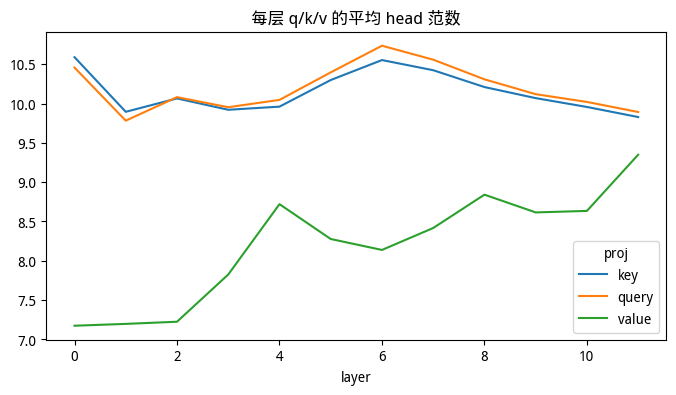

In [9]:
# 各层 q/k/v 的平均 head 范数走势
attn_df.groupby(["layer","proj"]).head_l2norm.mean().unstack().plot(figsize=(8,4))
plt.title("每层 q/k/v 的平均 head 范数")
plt.show()

In [10]:
# 相邻两层对应权重的余弦相似度（越低 = 层间差异越大）
def cos(a, b):
    a, b = a.detach().cpu().flatten().double(), b.detach().cpu().flatten().double()
    return float(a @ b / (a.norm() * b.norm()))

comps = ["attention.self.query.weight", "attention.self.key.weight",
         "attention.self.value.weight", "attention.output.dense.weight",
         "intermediate.dense.weight", "output.dense.weight"]
sim = pd.DataFrame({c: [
    round(cos(sd[f"bert.encoder.layer.{i}.{c}"], sd[f"bert.encoder.layer.{i+1}.{c}"]), 3)
    for i in range(n_layers-1)] for c in comps})
sim.index = [f"{i}-{i+1}" for i in range(n_layers-1)]
sim

,attention.self.query.weight,attention.self.key.weight,attention.self.value.weight,attention.output.dense.weight,intermediate.dense.weight,output.dense.weight
0-1,-0.002,0.004,0.000,-0.001,0.022,0.002
1-2,0.001,-0.002,-0.001,-0.004,0.022,0.000
2-3,0.003,0.003,-0.000,-0.001,0.024,0.001
3-4,-0.004,-0.000,0.002,0.004,0.021,0.002
4-5,0.000,0.003,-0.001,0.001,0.019,0.002
5-6,-0.003,-0.000,0.002,-0.000,0.017,0.002
6-7,0.002,-0.000,0.001,0.001,0.017,-0.000
7-8,0.003,0.001,0.000,0.000,0.021,0.002
8-9,0.003,-0.001,0.000,-0.001,0.023,0.002
9-10,-0.001,-0.003,0.000,-0.000,0.027,0.000


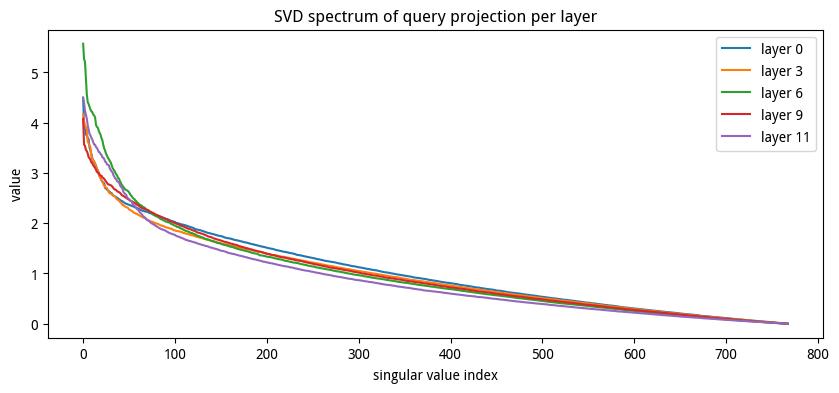

In [11]:
# 每层 query 矩阵的奇异值谱：看有效秩
plt.figure(figsize=(10,4))
for L in [0, 3, 6, 9, 11]:
    s = torch.linalg.svdvals(sd[f"bert.encoder.layer.{L}.attention.self.query.weight"])
    plt.plot(s.numpy(), label=f"layer {L}")
plt.legend(); plt.xlabel("singular value index"); plt.ylabel("value")
plt.title("SVD spectrum of query projection per layer")
plt.show()

## 目标②③ 两台模型跑同一输入，逐层对比

**关键点**：两个模型必须用**同一个 tokenizer、同一批输入**，每层的 hidden state 才对齐。

In [12]:
TEXTS = [
    "北京天气怎么样，明天会下雨吗？",
    "这个项目的核心目标是提升模型的每一层利用率，而不是只用最后一层。",
]

@torch.no_grad()
def run_and_capture(model, texts, max_len=64):
    enc = tokenizer(texts, padding=True, truncation=True, max_length=max_len,
                    return_tensors="pt").to(DEVICE)
    out = model(**enc, output_hidden_states=True, output_attentions=True)
    return enc, out

enc, out_ft   = run_and_capture(finetuned, TEXTS)
_,   out_base = run_and_capture(base, TEXTS)
print("hidden_states 数:", len(out_ft.hidden_states), "| attentions 数:", len(out_ft.attentions))
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print("tokens:", tokens[:15], "...")

hidden_states 数: 13 | attentions 数: 12
tokens: ['[CLS]', '北', '京', '天', '气', '怎', '么', '样', '，', '明', '天', '会', '下', '雨', '吗'] ...


### ② 原模型 / 微调模型 逐层激活统计（13 个：embedding + 12 层）

In [13]:
def layer_activation_stats(hs):
    rows = []
    for i, t in enumerate(hs):
        t = t.float()
        rows.append({
            "layer": i,
            "cls_norm": round(t[:, 0].norm(dim=-1).mean().item(), 3),
            "mean_abs": round(t.abs().mean().item(), 4),
            "std": round(t.std().item(), 4),
            "max_abs": round(t.abs().max().item(), 3),
        })
    return pd.DataFrame(rows)

astat_ft = layer_activation_stats(out_ft.hidden_states)   # 微调模型
astat_base = layer_activation_stats(out_base.hidden_states)  # 原模型
print("=== 微调模型 ==="); astat_ft

=== 微调模型 ===


,layer,cls_norm,mean_abs,std,max_abs
0,0,10.431,0.4318,0.5488,7.642
1,1,10.849,0.4822,0.6807,10.425
2,2,12.694,0.4448,0.6854,12.068
3,3,14.163,0.4217,0.6604,13.882
4,4,12.491,0.4475,0.7246,14.586
5,5,11.946,0.4332,0.7360,15.615
6,6,10.249,0.4324,0.7681,16.806
7,7,10.779,0.4527,0.7387,13.177
8,8,11.576,0.4541,0.7137,15.618
9,9,13.123,0.4679,0.7661,24.445


In [14]:
print("=== 原模型 ==="); astat_base

=== 原模型 ===


,layer,cls_norm,mean_abs,std,max_abs
0,0,10.430,0.4319,0.5488,7.645
1,1,10.841,0.4821,0.6805,10.427
2,2,12.690,0.4434,0.6842,12.083
3,3,14.154,0.4202,0.6590,13.874
4,4,12.487,0.4457,0.7239,14.576
5,5,11.946,0.4297,0.7348,15.629
6,6,10.244,0.4282,0.7668,16.831
7,7,10.773,0.4499,0.7383,13.201
8,8,11.571,0.4515,0.7140,16.019
9,9,13.126,0.4640,0.7688,24.863


### ③ 激活级对比：逐层余弦相似度 / L2 距离 / 绝对差

In [15]:
rows = []
for i, (x, y) in enumerate(zip(out_ft.hidden_states, out_base.hidden_states)):
    x, y = x.float(), y.float()
    rows.append({
        "layer": i,
        "cos": round(torch.cosine_similarity(x, y, dim=-1).mean().item(), 4),
        "mean_l2_dist": round((x - y).norm(dim=-1).mean().item(), 4),
        "mean_abs_diff": round((x - y).abs().mean().item(), 4),
    })
acomp = pd.DataFrame(rows)
acomp

,layer,cos,mean_l2_dist,mean_abs_diff
0,0,1.0000,0.0861,0.0025
1,1,0.9998,0.3935,0.0113
2,2,0.9993,0.6658,0.0191
3,3,0.9988,0.8523,0.0245
4,4,0.9983,1.1368,0.0325
5,5,0.9977,1.3470,0.0385
6,6,0.9972,1.5640,0.0447
7,7,0.9960,1.8051,0.0517
8,8,0.9943,2.0431,0.0585
9,9,0.9925,2.3576,0.0675


In [16]:
# 注意力矩阵本身也对比
rows = []
for i, (a, b) in enumerate(zip(out_ft.attentions, out_base.attentions)):
    rows.append({"layer": i,
                 "attn_cos": round(torch.cosine_similarity(a.float(), b.float(), dim=-1).mean().item(), 4)})
acmp = pd.DataFrame(rows)
acmp

,layer,attn_cos
0,0,0.9999
1,1,0.9996
2,2,0.9992
3,3,0.9989
4,4,0.9991
5,5,0.9983
6,6,0.9985
7,7,0.9978
8,8,0.9983
9,9,0.9959


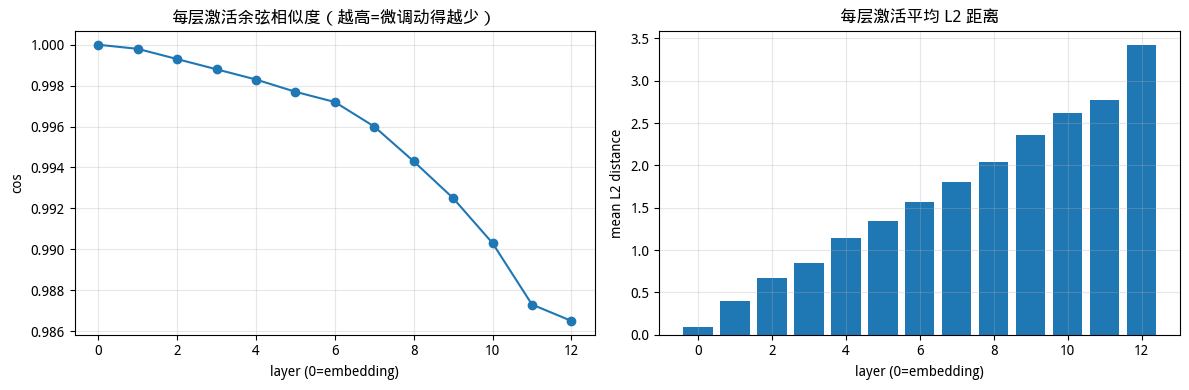

In [17]:
# 对比曲线：激活余弦相似度 / L2 距离
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(acomp["layer"], acomp["cos"], marker="o")
ax1.set_xlabel("layer (0=embedding)"); ax1.set_ylabel("cos")
ax1.set_title("每层激活余弦相似度（越高=微调动得越少）"); ax1.grid(alpha=.3)

ax2.bar(acomp["layer"], acomp["mean_l2_dist"])
ax2.set_xlabel("layer (0=embedding)"); ax2.set_ylabel("mean L2 distance")
ax2.set_title("每层激活平均 L2 距离"); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

### ③ 权重级对比：微调后的权重 vs 底座权重

In [18]:
def wlayer(k):   # 从去掉 bert. 前缀的 key 提取层号
    p = k.split(".")
    if "embeddings" in p: return "emb"
    if p[0] == "pooler": return "pooler"
    if "layer" in p: return int(p[2])
    return "other"

# 注意：微调对这个 backbone 改动很小（权重差异 ~1e-3 量级），
# 用 cos 到 4 位小数会全部显示 1.0，所以改用更高精度 + 绝对差 / 相对 L2 变化。
base_sd = base.state_dict()
wrows = []
for k, v in keep.items():
    if k in base_sd and v.shape == base_sd[k].shape:
        vb, b = v.float().detach().cpu(), base_sd[k].float().detach().cpu()
        wrows.append({
            "weight": k,
            "layer": wlayer(k),
            "cos": round(cos(v, base_sd[k]), 6),
            "mean_abs_diff": round((vb - b).abs().mean().item(), 6),
            "rel_l2": round(((vb - b).norm() / (b.norm() + 1e-12)).item(), 6),
        })
wcmp = pd.DataFrame(wrows)

print("微调改动最大（与底座差异最大）的权重：")
print(wcmp.nlargest(8, "mean_abs_diff")[["weight", "layer", "mean_abs_diff", "rel_l2"]].to_string(index=False))
print("\n微调改动最小的权重：")
print(wcmp.nsmallest(8, "mean_abs_diff")[["weight", "layer", "mean_abs_diff", "rel_l2"]].to_string(index=False))

微调改动最大（与底座差异最大）的权重：
                                      weight  layer  mean_abs_diff   rel_l2
                         pooler.dense.weight pooler       0.000167 0.005086
  encoder.layer.10.attention.self.query.bias     10       0.000165 0.000923
   encoder.layer.8.attention.self.query.bias      8       0.000154 0.000981
encoder.layer.10.attention.self.query.weight     10       0.000154 0.004618
  encoder.layer.10.attention.self.key.weight     10       0.000151 0.004521
   encoder.layer.9.attention.self.query.bias      9       0.000149 0.001045
   encoder.layer.9.attention.self.key.weight      9       0.000148 0.004519
 encoder.layer.9.attention.self.query.weight      9       0.000142 0.004229

微调改动最小的权重：
                                  weight layer  mean_abs_diff   rel_l2
encoder.layer.10.attention.self.key.bias    10       0.000001 0.000117
 encoder.layer.0.attention.self.key.bias     0       0.000002 0.000362
 encoder.layer.1.attention.self.key.bias     1       0.000002 0.000294


In [19]:
# 每层权重与底座的平均差异（rel_l2 / mean_abs_diff 越大 = 该层被改得越多）
wl = wcmp[wcmp["layer"].apply(lambda x: isinstance(x, int))]
wl.groupby("layer")[["cos", "mean_abs_diff", "rel_l2"]].mean().round(6)

,cos,mean_abs_diff,rel_l2
layer,,,
0,0.999997,0.000103,0.001874
1,0.999997,0.000103,0.001990
2,0.999997,0.000103,0.002080
3,0.999997,0.000106,0.002206
4,0.999996,0.000105,0.002248
5,0.999996,0.000107,0.002269
6,0.999997,0.000104,0.002142
7,0.999997,0.000104,0.002118
8,0.999996,0.000107,0.002216


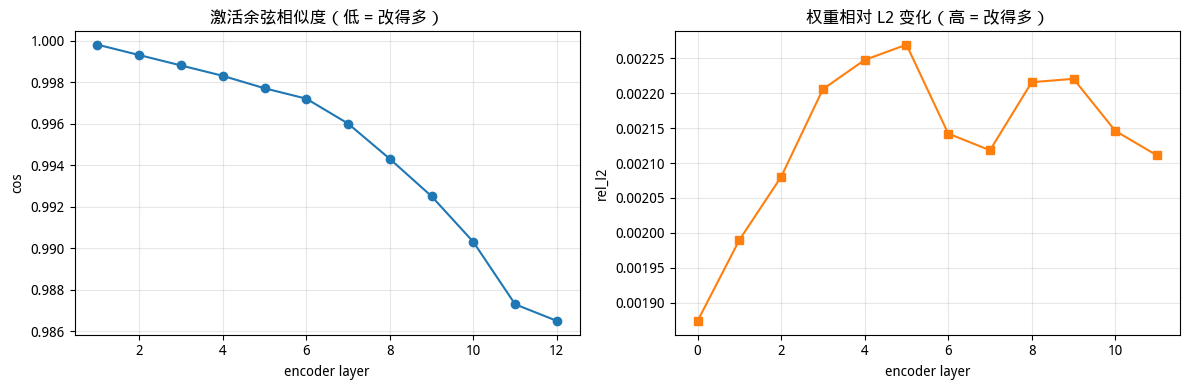

In [20]:
# 两个面板：左=激活级变化，右=权重级变化（encoder layer j 的激活对应 hidden index j+1）
wmean = wl.groupby("layer")[["rel_l2"]].mean().sort_index()
hid_idx = wmean.index + 1
act_cos = acomp.set_index("layer").loc[hid_idx, "cos"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hid_idx, act_cos.values, marker="o", color="tab:blue")
ax1.set_title("激活余弦相似度（低 = 改得多）")
ax1.set_xlabel("encoder layer"); ax1.set_ylabel("cos"); ax1.grid(alpha=.3)

ax2.plot(wmean.index, wmean["rel_l2"].values, marker="s", color="tab:orange")
ax2.set_title("权重相对 L2 变化（高 = 改得多）")
ax2.set_xlabel("encoder layer"); ax2.set_ylabel("rel_l2"); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 小结

- **目标①** 权重统计 / per-head / 跨层相似度 / SVD → 微调模型自身的层次结构
- **目标②** 两个模型同一输入跑前向 → 逐层激活统计
- **目标③** 逐层余弦 / L2 / 权重差异 → 定位微调动了哪些层

**一个重要发现**：这个 ckpt 的 `bert.*` 权重与底座 `chinese-roberta-wwm-ext` 几乎相同
（所有权重最大绝对误差约 1.5e-3），微调对 backbone 的改动非常小——真正的变化集中在：
- **高层**（layer 8-12）的激活和权重（激活余弦从 0.98+ 逐步下滑）
- 自定义的 **`fc` 分类头**（shape [2, 768]，2 分类）

后续如需要：④ 注意力 head 分工 + 分层探针；⑤ 每层加分类头（early-exit）。